#Environment Setup

In [1]:
# Install PySpark and initialize Spark Session
import sys
!{sys.executable} -m pip install pyspark


In [2]:
pip install --upgrade pyspark

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pyspark.sql import SparkSession

In [4]:
import sys
print("Python path:", sys.executable)
print("Python version:", sys.version)

!{sys.executable} -m pip show pyspark

Python path: c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Scripts\python.exe
Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Name: pyspark
Version: 4.1.1
Summary: Apache Spark Python API
Home-page: https://github.com/apache/spark/tree/master/python
Author: Spark Developers
Author-email: dev@spark.apache.org
License: Apache-2.0
Location: c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages
Requires: py4j
Required-by: 


#Data Loading

In [5]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/comprehensive-medical-q-a-dataset")

print("Path to dataset files:", path)

c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Khaled\.cache\kagglehub\datasets\thedevastator\comprehensive-medical-q-a-dataset\versions\2


In [7]:
import os
file_path = os.path.join(path, "train.csv")
import os

file_path = os.path.join(path, "train.csv")
print("File path:", file_path)
print(" File exists:", os.path.exists(file_path))

File path: C:\Users\Khaled\.cache\kagglehub\datasets\thedevastator\comprehensive-medical-q-a-dataset\versions\2\train.csv
 File exists: True


In [8]:
import os

# Force Java 17
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, concat, lit, when, lower, trim,
    split, size, length, regexp_replace, element_at
)


In [9]:
import os

# Java 17
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

# Hadoop
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\hadoop\bin;" + os.environ["PATH"]

print("✓ Java & Hadoop configured")

✓ Java & Hadoop configured


In [10]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Medical_QA_Preprocessing") \
    .getOrCreate()

df = spark.read.csv(file_path, header=True, inferSchema=True)

print(f"Spark session created")
print(f"Data loaded — {df.count()} rows, {len(df.columns)} columns")
print(f"Columns: {df.columns}")
df.select("qtype", "Question", "Answer").show(3, truncate=False)

Spark session created
Data loaded — 38088 rows, 3 columns
Columns: ['qtype', 'Question', 'Answer']
+--------------------------------------+---------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|qtype                                 |Question                                                                                                                         |Answer                                                                                      

#Data Cleaning & Transformation

In [11]:
#Data Cleaning & Transformation

from pyspark.sql.functions import col, split, size, lower, trim

# Convert text to lowercase and remove leading/trailing whitespace
# This ensures consistent text format before further processing
df_clean = df.withColumn("Question", lower(trim(col("Question")))) \
             .withColumn("Answer", lower(trim(col("Answer")))) \
             .withColumn("qtype", lower(trim(col("qtype"))))

# Drop rows where Question or Answer is null to avoid errors downstream
df_clean = df_clean.dropna(subset=["Question", "Answer"])        
print(f"After dropping nulls: {df_clean.count()} rows")          

# Calculate word count for each Question and Answer
# These columns are used for EDA figures and outlier detection
df_eda = df_clean.withColumn("q_len", size(split(col("Question"), " "))) \
                 .withColumn("a_len", size(split(col("Answer"), " ")))

print("Summary Statistics for Token/Word Counts:")
df_eda.select("q_len", "a_len").describe().show()

After dropping nulls: 23831 rows
Summary Statistics for Token/Word Counts:
+-------+------------------+------------------+
|summary|             q_len|             a_len|
+-------+------------------+------------------+
|  count|             23831|             23831|
|   mean|10.258780579916914|105.11703243674206|
| stddev|13.481457245933242| 126.3072343140169|
|    min|                 1|                 1|
|    max|               214|              1960|
+-------+------------------+------------------+



#Exploratory Data Analysis - EDA

#Visualization 1: Distribution of Question lengths


In [12]:
%pip install matplotlib seaborn scikit-learn rouge-score nltk kagglehub pyspark

Note: you may need to restart the kernel to use updated packages.


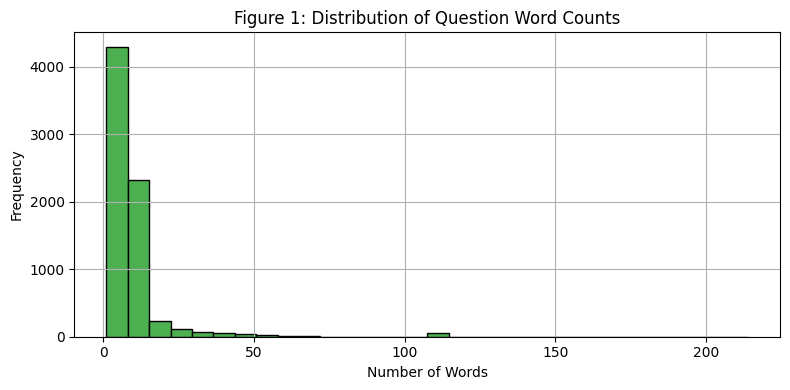

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample 30% of data for efficient plotting
pdf = df_eda.select("q_len", "a_len", "qtype").sample(fraction=0.3, seed=42).toPandas()

# Figure 1: Distribution of question word counts
# This helps identify outliers (very short or very long questions)
plt.figure(figsize=(8, 4))
pdf['q_len'].hist(bins=30, color='#4CAF50', edgecolor='black')
plt.title('Figure 1: Distribution of Question Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("fig1_question_length.png", dpi=150)  
plt.show()

Visualization 2: Top 10 Question Types (Label Balance)

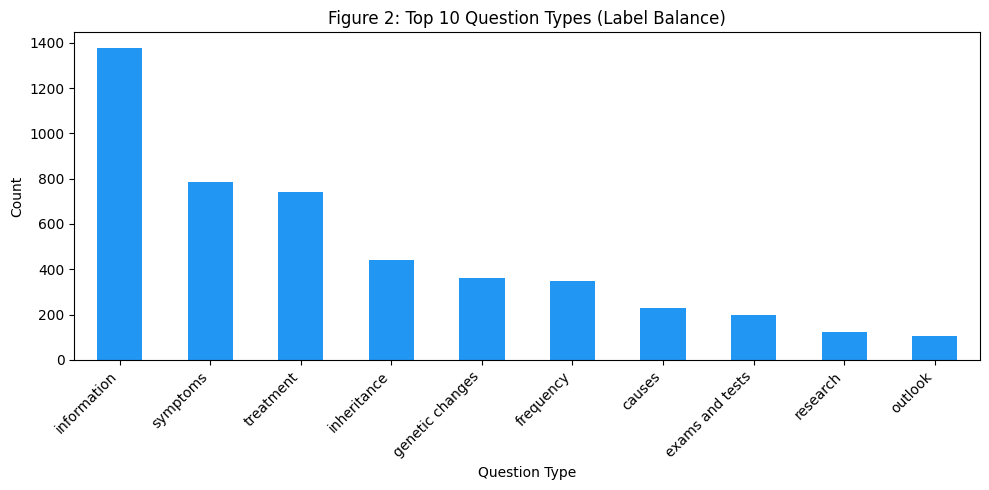

In [14]:
# show which medical categories are most represented
# in the dataset. Imbalanced labels may affect model performance.
plt.figure(figsize=(10, 5))
pdf['qtype'].value_counts().head(10).plot(kind='bar', color='#2196F3')
plt.title('Figure 2: Top 10 Question Types (Label Balance)')
plt.xlabel('Question Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("fig2_label_balance.png", dpi=150)
plt.show()

Visualization 3: Relationship between Question and Answer Length

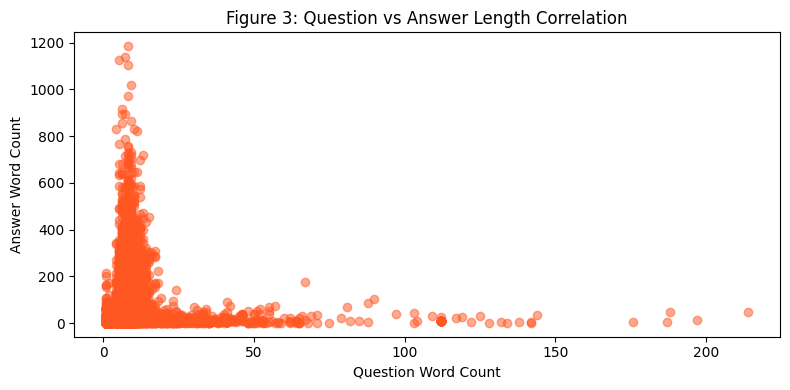

In [15]:
# This scatter plot shows whether longer questions tend to
# have longer answers, which affects max_seq_length choice.
plt.figure(figsize=(8, 4))
plt.scatter(pdf['q_len'], pdf['a_len'], alpha=0.5, color='#FF5722')
plt.title('Figure 3: Question vs Answer Length Correlation')
plt.xlabel('Question Word Count')
plt.ylabel('Answer Word Count')
plt.tight_layout()
plt.savefig("fig3_q_vs_a_scatter.png", dpi=150)
plt.show()

Visualization 4: Distribution of Top 5 Medical Question Types (Pie Chart)

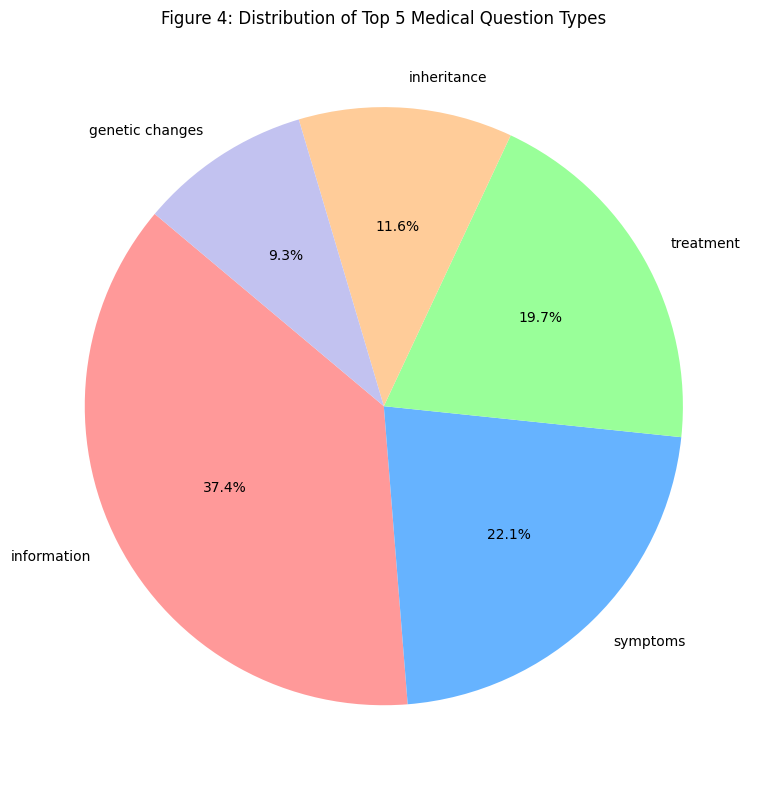

In [16]:
# clearer view of the dominant categories
# after cleaning the qtype column (some have "prefix: type" format)
from pyspark.sql.functions import col, split, element_at, trim, when

df_for_qtype_plot = df_eda.withColumn("qtype_clean",
    when(col("qtype").contains(":"), trim(element_at(split(col("qtype"), ":"), -1)))
    .otherwise(col("qtype")))

df_for_qtype_plot = df_for_qtype_plot.filter(
    (col("a_len") >= 10) & (col("a_len") <= 500) &
    (col("q_len") >= 5)
)

qtype_counts = df_for_qtype_plot.groupBy("qtype_clean").count() \
    .orderBy("count", ascending=False).limit(5).toPandas()

plt.figure(figsize=(8, 8))
plt.pie(qtype_counts['count'], labels=qtype_counts['qtype_clean'],
        autopct='%1.1f%%', startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])
plt.title("Figure 4: Distribution of Top 5 Medical Question Types")
plt.tight_layout()
plt.savefig("fig4_top5_categories.png", dpi=150)
plt.show()

In [17]:
# Clean the qtype column: extract the actual type after "
from pyspark.sql.functions import split, element_at

df_refined = df_eda.withColumn("qtype_clean",
    when(col("qtype").contains(":"), trim(element_at(split(col("qtype"), ":"), -1)))
    .otherwise(col("qtype")))

In [18]:
# Analyze answer length distribution to decide outlier thresholds
# We check how many rows exceed 250 and 500 words to set a reasonable upper bound for filtering
print("=== Answer Length Statistics ===")
df_eda.select(col("a_len").alias("answer_words")).describe().show()

total_rows = df_eda.count()

rows_gt_500 = df_eda.filter(col('a_len') > 500).count()
percentage_gt_500 = (rows_gt_500 / total_rows) * 100 if total_rows > 0 else 0

rows_gt_250 = df_eda.filter(col('a_len') > 250).count()
percentage_gt_250 = (rows_gt_250 / total_rows) * 100 if total_rows > 0 else 0

print(f"\nRows > 500 words: {rows_gt_500} ({percentage_gt_500:.1f}%)")
print(f"Rows > 250 words: {rows_gt_250} ({percentage_gt_250:.1f}%)")
print("\n→ We choose 500 as the upper limit to keep most data while "
      "fitting within the model's max_seq_length of 2048 tokens.")


=== Answer Length Statistics ===
+-------+------------------+
|summary|      answer_words|
+-------+------------------+
|  count|             23831|
|   mean|105.11703243674206|
| stddev| 126.3072343140169|
|    min|                 1|
|    max|              1960|
+-------+------------------+


Rows > 500 words: 320 (1.3%)
Rows > 250 words: 2991 (12.6%)

→ We choose 500 as the upper limit to keep most data while fitting within the model's max_seq_length of 2048 tokens.


In [19]:
# Remove outliers:
# Questions < 5 words: too short to be meaningful medical questions
# Answers < 10 words: too brief for useful medical guidance
# Answers > 500 words: too long for model's context window (2048 tokens)
df_filtered = df_refined.filter(
    (col("a_len") >= 10) & (col("a_len") <= 500) &
    (col("q_len") >= 5)
)

print(f"Rows after filtering outliers: {df_filtered.count()}")

Rows after filtering outliers: 17483


In [20]:
# Final text cleanup + deduplication
df_final_clean = df_filtered \
    .withColumn("Answer",   regexp_replace(col("Answer"),   r"\s+", " ")) \
    .withColumn("Question", regexp_replace(col("Question"), r"\s+", " ")) \
    .dropDuplicates(["Question", "Answer"])

print(f"Final clean dataset: {df_final_clean.count()} rows")

Final clean dataset: 17045 rows


#Formatting for LLM

In [21]:
# Format each row as a ChatML conversation for Qwen2.5-Instruct ChatML uses <|im_start|> and <|im_end|> tokens to separate
# system instructions, user questions, and assistant answers.
from pyspark.sql.functions import concat, lit

df_templated = df_final_clean.withColumn("text",
    concat(
        lit("<|im_start|>system\nYou are a professional medical assistant. "
            "Answer the patient's questions accurately.<|im_end|>\n"),
        lit("<|im_start|>user\n"),      col("Question"), lit("<|im_end|>\n"),
        lit("<|im_start|>assistant\n"), col("Answer"),   lit("<|im_end|>")
    )
)

print(f"ChatML formatting applied — {df_templated.count()} rows")

ChatML formatting applied — 17045 rows


In [22]:
# Safety filter: remove rows where Question or Answer is too short after character-level check (complements the word-level filter above)
from pyspark.sql.functions import length

df_final = df_templated.filter(
    (length(col("Question")) > 20) &
    (length(col("Answer"))   > 40)
)

print(f" After character-length filter: {df_final.count()} rows")
df_final.select("text").show(1, truncate=False)

 After character-length filter: 17023 rows
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text                                                                                                                                                                                                                                                                                                                                                                                                          |
+----------------------------------------------------------------------------------------------------------------------------------------------------------

Data Splitting & Export

In [23]:
# Split data into Train (70%), Validation (15%), Test (15%)
# Using fixed seed=42 to ensure reproducibility and prevent
# data leakage between splits.
train_df, val_df, test_df = df_final.randomSplit([0.7, 0.15, 0.15], seed=42)

print(f"Train samples:      {train_df.count()}")
print(f"Validation samples: {val_df.count()}")
print(f"Test samples:       {test_df.count()}")

# Save as JSON files — on EMR these paths would be S3
# coalesce(1) ensures a single output file per split
OUTPUT_DIR = "."  # Change to S3 path on EMR: "s3://YOUR-BUCKET/output/"

train_df.select("text").coalesce(1).write.mode("overwrite") \
    .json(f"{OUTPUT_DIR}/medical_train")
val_df.select("text").coalesce(1).write.mode("overwrite") \
    .json(f"{OUTPUT_DIR}/medical_val")
test_df.select("text").coalesce(1).write.mode("overwrite") \
    .json(f"{OUTPUT_DIR}/medical_test")

# Save test Q&A pairs separately for evaluation after fine-tuning
test_df.select("Question", "Answer").coalesce(1).write.mode("overwrite") \
    .json(f"{OUTPUT_DIR}/medical_test_qa")

print(" All output files saved")

Train samples:      12033
Validation samples: 2507
Test samples:       2483
 All output files saved


Visualization 5: Sample Count Per Split

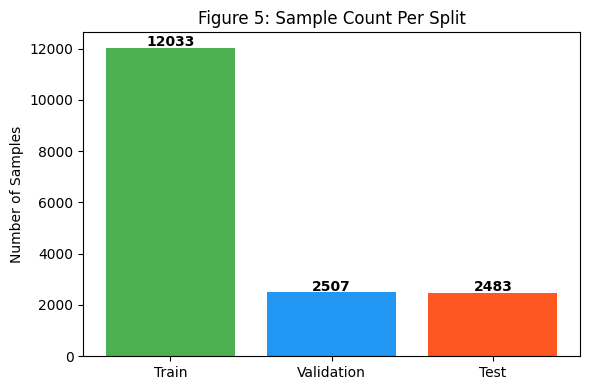

In [24]:
# Shows the distribution of data across train/validation/test sets
import matplotlib.pyplot as plt

split_counts = {
    "Train": train_df.count(),
    "Validation": val_df.count(),
    "Test": test_df.count()
}

plt.figure(figsize=(6, 4))
bars = plt.bar(split_counts.keys(), split_counts.values(),
               color=["#4CAF50", "#2196F3", "#FF5722"])
plt.title("Figure 5: Sample Count Per Split")
plt.ylabel("Number of Samples")
for i, (k, v) in enumerate(split_counts.items()):
    plt.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_split_counts.png", dpi=150)
plt.show()

#Data Splitting & Expor

In [25]:
from pyspark.sql.functions import concat, lit, length

df_with_text = df_final_clean.withColumn("text",
    concat(
        lit("<|im_start|>system\nYou are a professional medical assistant."
            " Answer the patient's questions accurately.<|im_end|>\n"),
        lit("<|im_start|>user\n"), col("Question"), lit("<|im_end|>\n"),
        lit("<|im_start|>assistant\n"), col("Answer"), lit("<|im_end|>")
    )
)

train_df, val_df, test_df = df_with_text.randomSplit([0.7, 0.15, 0.15], seed=42)

print(f"Train: {train_df.count()}")
print(f"Val:   {val_df.count()}")
print(f"Test:  {test_df.count()}")

import os
os.makedirs("data_splits", exist_ok=True)

train_df.select("text").toPandas().to_json(
    "data_splits/train.jsonl", orient="records", lines=True
)
val_df.select("text").toPandas().to_json(
    "data_splits/val.jsonl", orient="records", lines=True
)
test_df.select("Question", "Answer").toPandas().to_json(
    "data_splits/test_qa.jsonl", orient="records", lines=True
)

print(" All files saved")

Train: 12051
Val:   2509
Test:  2485
 All files saved


In [26]:
import os
# find path
def get_json_path(folder_name):
    files = os.listdir(folder_name)
    for f in files:
        if f.endswith(".json"):
            return os.path.join(folder_name, f)


train_path = "data_splits/train.jsonl"
val_path   = "data_splits/val.jsonl"
test_qa_path = "data_splits/test_qa.jsonl"

print(f"path training file: {train_path}")
print(f"path test file: {val_path}")

path training file: data_splits/train.jsonl
path test file: data_splits/val.jsonl


#Fine-tuning

In [27]:
#%pip install unsloth
#%pip install --no-deps xformers trl peft accelerate bitsandbytes

In [28]:
import sys
print(sys.executable)

c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Scripts\python.exe


In [29]:
#%pip uninstall torch torchvision torchaudio -y
#%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

In [30]:
import sys
print(sys.executable)

import torch
print(f"Version: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

from unsloth import FastLanguageModel
print("✓ Unsloth loaded")

c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Scripts\python.exe
Version: 2.10.0+cu126
CUDA: True
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0430 16:30:03.923000 28160 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
✓ Unsloth loaded


In [31]:
import torch

print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

torch version: 2.10.0+cu126
CUDA available: True
CUDA version: 12.6
GPU name: NVIDIA RTX 5000 Ada Generation


In [37]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048  
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/qwen2.5-1.5b-instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    load_in_4bit=load_in_4bit,
)

# Fix pad token
if tokenizer.pad_token is None or tokenizer.pad_token == tokenizer.eos_token:
    tokenizer.pad_token = "<|endoftext|>"
    tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids("<|endoftext|>")

print("✓ Model loaded")


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX 5000 Ada Generation. Num GPUs = 1. Max memory: 31.992 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 781.22it/s]


unsloth/qwen2.5-1.5b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✓ Model loaded


In [38]:
# BASE MODEL Response — BEFORE Fine-Tuning

FastLanguageModel.for_inference(model)

test_questions = [
    "What are the symptoms of diabetes?",
    "How is hypertension treated?",
    "What causes migraine headaches?",
]

base_responses = []
for q in test_questions:
    messages = [
        {"role": "system", "content": "You are a professional medical assistant."},
        {"role": "user", "content": q}
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")
    attention_mask = (inputs != tokenizer.pad_token_id).long()
    outputs = model.generate(
        input_ids=inputs, attention_mask=attention_mask,
        max_new_tokens=512, temperature=0.7, do_sample=True,
        top_p=0.9, repetition_penalty=1.1,
    )
    resp = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)
    base_responses.append(resp)
    print(f"\nQ: {q}")
    print(f"BASE: {resp[:400]}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What are the symptoms of diabetes?
BASE: The symptoms of diabetes can vary in severity and may not always be noticeable. The following are some common signs:

1. Frequent urination: People with diabetes often need to urinate more frequently, especially at night.

2. Excessive thirst or dry mouth: Diabetes causes your body to have an increased thirst because it is unable to use glucose for energy.

3. Extreme hunger: Because the body cann


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: How is hypertension treated?
BASE: Hypertension, also known as high blood pressure, can be effectively managed through various methods. The treatment approach varies depending on the individual's condition and the presence of complications. Here are some common strategies:

1. Lifestyle Modifications:
- Diet: A low-sodium diet rich in fruits, vegetables, whole grains, lean proteins, and healthy fats.
- Exercise: Regular physical ac

Q: What causes migraine headaches?
BASE: Migraine headaches can be caused by several factors, including:

1. Genetics: If you have a family history of migraines, you are more likely to experience them.

2. Hormonal changes: Women are more prone to migraines because they experience hormonal fluctuations during their menstrual cycle or menopause.

3. Food triggers: Certain foods and drinks, such as chocolate, cheese, red wine, and coffee, 


In [39]:
# Add LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
)

print("✓ LoRA adapters added")

✓ LoRA adapters added


In [40]:
from datasets import load_dataset
dataset = load_dataset("json", data_files={
    "train": train_path,
    "validation": val_path
})

Generating train split: 12051 examples [00:00, 345986.80 examples/s]
Generating validation split: 2509 examples [00:00, 289218.62 examples/s]


The Training Loop

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    args=TrainingArguments(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        warmup_steps=50,
        num_train_epochs=2,
        learning_rate=2e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=42,
        output_dir="outputs",
        eval_strategy="steps",
        eval_steps=500,
        save_strategy="no",         
        save_only_model=True,        
        report_to="none",
    ),
)

trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 12,033 | Num Epochs = 2 | Total steps = 3,010
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss,Validation Loss
500,0.985119,1.026607
1000,0.983478,0.987684
1500,0.948248,0.961950
2000,0.893064,0.953632
2500,0.992949,0.942616
3000,0.896095,0.937916
3010,0.981791,0.937788


c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [41]:
# Hyperparameter Summary Table
import pandas as pd

hyperparams = {
    "Parameter": [
        "Base Model", "Parameters", "Quantization",
        "LoRA Rank (r)", "LoRA Alpha", "LoRA Dropout",
        "Target Modules", "Learning Rate", "Batch Size (effective)",
        "Gradient Accumulation", "Epochs", "Warmup Steps",
        "Optimizer", "Weight Decay", "Scheduler",
        "Max Sequence Length", "Train Samples", "Val Samples",
    ],
    "Value": [
        "Qwen 2.5 1.5B Instruct", "1.56B", "4-bit (BnB)",
        "16", "16", "0",
        "q,k,v,o,gate,up,down_proj", "2e-4", "8 (1×8)",
        "8", "2", "50",
        "AdamW 8-bit", "0.01", "Linear",
        "2048", str(len(dataset["train"])), str(len(dataset["validation"])),
    ],
}

hp_df = pd.DataFrame(hyperparams)
print(hp_df.to_string(index=False))

             Parameter                     Value
            Base Model    Qwen 2.5 1.5B Instruct
            Parameters                     1.56B
          Quantization               4-bit (BnB)
         LoRA Rank (r)                        16
            LoRA Alpha                        16
          LoRA Dropout                         0
        Target Modules q,k,v,o,gate,up,down_proj
         Learning Rate                      2e-4
Batch Size (effective)                   8 (1×8)
 Gradient Accumulation                         8
                Epochs                         2
          Warmup Steps                        50
             Optimizer               AdamW 8-bit
          Weight Decay                      0.01
             Scheduler                    Linear
   Max Sequence Length                      2048
         Train Samples                     12051
           Val Samples                      2509


In [ ]:
model.save_pretrained("medical_qa_model_lora")
tokenizer.save_pretrained("medical_qa_model_lora")
print("✓ Model saved")

Unsloth: Restored added_tokens_decoder metadata in medical_qa_model_lora\tokenizer_config.json.


✓ Model saved


In [ ]:
# Export to GGUF Required for Ollama deployment 
model.save_pretrained_gguf(
    "medical_qa_gguf",
    tokenizer,
    quantization_method="q4_k_m",  # Good balance of quality vs size
)
print("✓ GGUF model exported to medical_qa_gguf/")

Training Curves

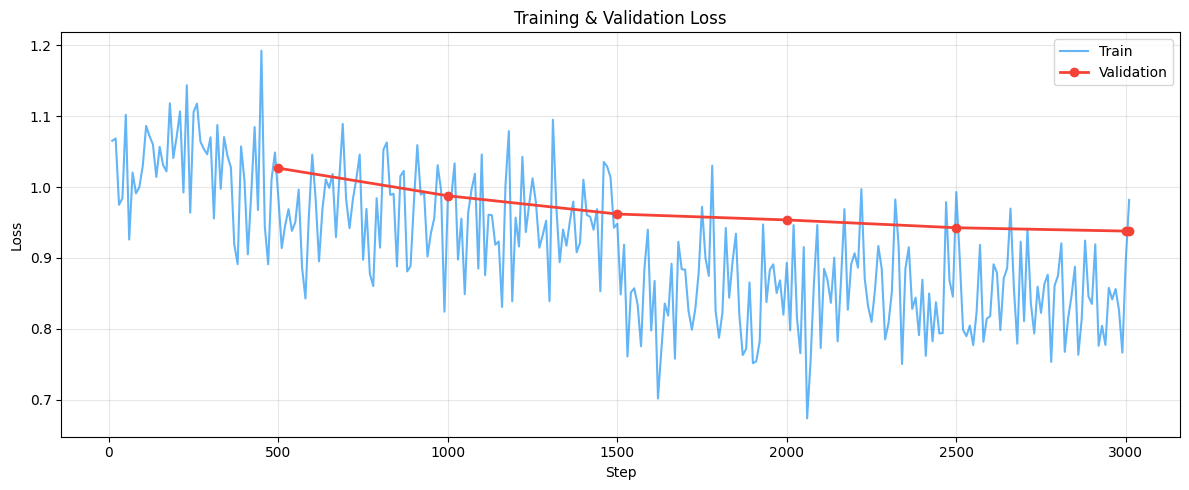

Saved training_curves.png


In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps  = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]
eval_steps_  = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_steps, train_losses, label='Train', alpha=0.7, color='#2196F3')
ax.plot(eval_steps_, eval_losses, label='Validation', color='#F44336',
        linewidth=2, marker='o', markersize=6)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")

Base vs Fine-tuned

In [ ]:
# Side-by-Side Comparison: Base vs Fine-Tuned
FastLanguageModel.for_inference(model)

finetuned_responses = []
for q in test_questions:
    messages = [
        {"role": "system", "content": "You are a professional medical assistant."},
        {"role": "user", "content": q}
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    attention_mask = (inputs != tokenizer.pad_token_id).long()
    outputs = model.generate(
        input_ids=inputs, attention_mask=attention_mask,
        max_new_tokens=512, temperature=0.7, do_sample=True,
        top_p=0.9, repetition_penalty=1.1,
    )
    resp = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)
    finetuned_responses.append(resp)

# Print side-by-side comparison
for i, q in enumerate(test_questions):
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    print(f"{'─'*60}")
    print(f"BASE:       {base_responses[i][:300]}")
    print(f"{'─'*60}")
    print(f"FINE-TUNED: {finetuned_responses[i][:300]}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What are the symptoms of diabetes?
A: the first sign that you may have prediabetes is an fbs level between 100 and less than or equal to 126. in this case, your blood sugar levels are higher than normal but not high enough for a diagnosis of diabetes.


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: How is hypertension treated?
A: a person with high blood pressure can delay or even prevent the need for medication by making lifestyle changes such as losing weight, eating less sodium (salt), and getting more physical activity. these changes may be all that a doctor recommends in mild cases of hypertension.

Q: What causes migraine headaches?
A: scientists aren't sure what causes migraines, but they think it's probably related to changes in the brain and chemicals released by blood vessels in the head that trigger pain. some people with migraines may also have an abnormality of their trigeminal nerve, which is one of 13 pairs of cranial nerves that carry sensory signals from the face and scalp to the brainstem and brain itself. scientists don't know if this nerve problem is the cause or whether it results from a migraine headache.


Evaluation (ROUGE + BLEU)

In [ ]:
import json
import numpy as np
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

test_qa_path = get_json_path("medical_test_qa")
test_qa_list = []
with open(test_qa_path, 'r') as f:
    for line in f:
        test_qa_list.append(json.loads(line))

np.random.seed(42)
eval_size = min(100, len(test_qa_list))
eval_idx = np.random.choice(len(test_qa_list), eval_size, replace=False)
eval_samples = [test_qa_list[i] for i in eval_idx]

print(f"Evaluating {eval_size} samples...")

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1
all_r1, all_r2, all_rL, all_bleu = [], [], [], []

for idx, sample in enumerate(eval_samples):
    messages = [
        {"role": "system", "content": "You are a professional medical assistant."},
        {"role": "user", "content": sample['Question']}
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")
    attention_mask = (inputs != tokenizer.pad_token_id).long()

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs,
            attention_mask=attention_mask,
            max_new_tokens=512,
            do_sample=False,
        )
    pred = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)
    ref = sample['Answer']

    scores = scorer.score(ref, pred)
    all_r1.append(scores['rouge1'].fmeasure)
    all_r2.append(scores['rouge2'].fmeasure)
    all_rL.append(scores['rougeL'].fmeasure)
    bleu = sentence_bleu([ref.split()], pred.split(), smoothing_function=smooth)
    all_bleu.append(bleu)

    if (idx + 1) % 25 == 0:
        print(f"  Done {idx+1}/{eval_size}")

results = {
    'ROUGE-1': np.mean(all_r1),
    'ROUGE-2': np.mean(all_r2),
    'ROUGE-L': np.mean(all_rL),
    'BLEU':    np.mean(all_bleu),
}

print(f"\n{'='*40}")
print(f"  TEST RESULTS ({eval_size} samples)")
print(f"{'='*40}")
for m, v in results.items():
    print(f"  {m}: {v:.4f}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Evaluating 100 samples...


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils

  Done 25/100


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Done 50/100


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Done 75/100


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Done 100/100

  TEST RESULTS (100 samples)
  ROUGE-1: 0.4199
  ROUGE-2: 0.2319
  ROUGE-L: 0.3171
  BLEU: 0.1628


Evaluation Chart

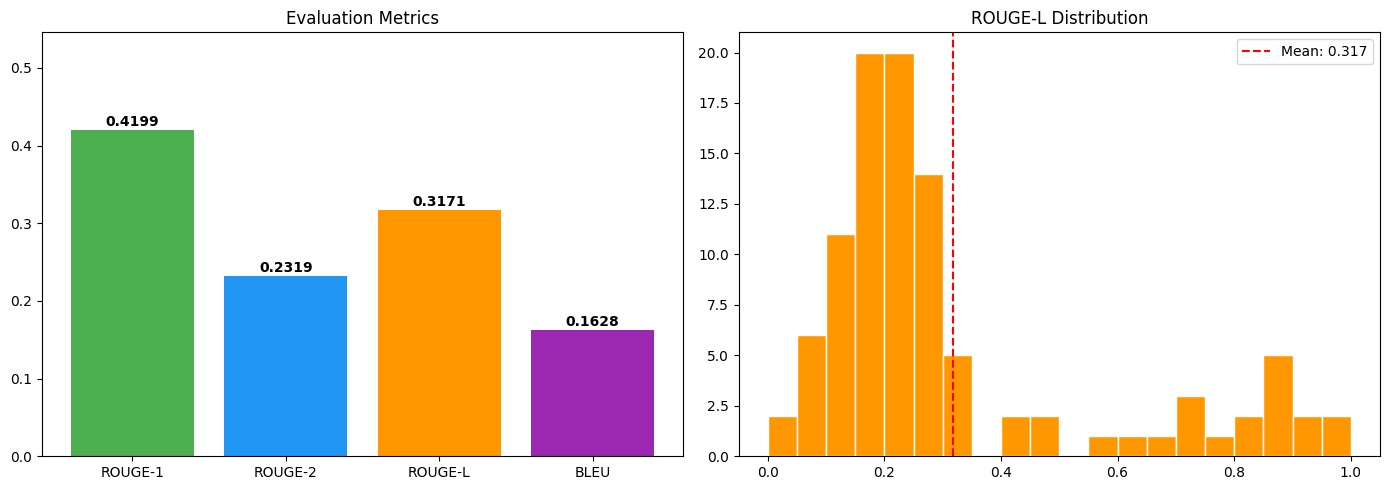

✓ Project Complete!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_m = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = axes[0].bar(results.keys(), results.values(), color=colors_m)
axes[0].set_ylim(0, max(results.values()) * 1.3)
axes[0].set_title('Evaluation Metrics')
for b, v in zip(bars, results.values()):
    axes[0].text(b.get_x() + b.get_width()/2., b.get_height() + 0.005,
                 f'{v:.4f}', ha='center', fontweight='bold')

axes[1].hist(all_rL, bins=20, color='#FF9800', edgecolor='white')
axes[1].axvline(np.mean(all_rL), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_rL):.3f}')
axes[1].set_title('ROUGE-L Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=150)
plt.show()

print("✓ Project Complete!")

# Test Model

In [ ]:
FastLanguageModel.for_inference(model)

def ask_doctor(question):
    messages = [
        {"role": "system", "content": "You are a professional medical assistant."},
        {"role": "user", "content": question}
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")
    
    attention_mask = (inputs != tokenizer.pad_token_id).long()
    
    outputs = model.generate(
        input_ids=inputs,
        attention_mask=attention_mask,
        max_new_tokens=512,
        temperature=0.7,
        do_sample=True,
        top_p=0.9,
        repetition_penalty=1.1,
    )
    return tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)

questions = [
    "What are the symptoms of pneumonia?",
    "How can I prevent heart disease?",
    "What is the treatment for asthma?",
    "What are the side effects of ibuprofen?",
    "How is tuberculosis diagnosed?",
]

for q in questions:
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    print(f"{'─'*60}")
    print(f"A: {ask_doctor(q)}")

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What are the symptoms of pneumonia?
────────────────────────────────────────────────────────────


c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
c:\Users\Khaled\Downloads\projects_vs_code\gpu_env\Lib\site-packages\transformers\modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/

A: the most common symptom of bacterial pneumonia is a cough with phlegm or mucus that produces a wet sound when tapped on the chest, fever, and chills. viral pneumonia often has no specific signs or symptoms other than those caused by the virus that infected you. however, it can cause flu-like symptoms such as high fever, shaking chills, and extreme fatigue. in severe cases, viral pneumonia can lead to respiratory failure.

Q: How can I prevent heart disease?
────────────────────────────────────────────────────────────


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: you can take steps to lower your risk of getting heart disease, including the following:

Q: What is the treatment for asthma?
────────────────────────────────────────────────────────────


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: medications can help prevent and control symptoms of asthma, including bronchodilators (bron-koh-dih-lay-torz) and corticosteroids (ko-rik-stur-dos). bronchodilators work by relaxing and widening the airways so you can breathe easier. you take them as needed or in advance when you think an attack might start. corticosteroid inhalers reduce swelling in the lining of your airways, which helps to open up the airway passages and makes it easier to breathe. corticosteroids also have anti-inflammatory properties that keep your airways from getting inflamed and swollen. nih: national heart, lung, and blood institute

Q: What are the side effects of ibuprofen?
────────────────────────────────────────────────────────────


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: ibuprofen can cause stomach upset, heartburn, and diarrhea. in rare cases, people take too much ibuprofen at one time to get relief from pain or fever and may develop bleeding problems or ulcers in their digestive tract.

Q: How is tuberculosis diagnosed?
────────────────────────────────────────────────────────────
A: a health care provider may diagnose active tb disease by using the following tests:
